# Does size matter? Exploring the relationship between population size, growth, and national happiness 
### Social Data Analysis and Visualization — Final Project
**DTU · Spring 2026**

---

> **Website:** [fridapfrandsen.github.io](https://fridapfrandsen.github.io)
>
> **Group:** Karen Stentoft (s253843), Frida Pilegaard Frandsen (s253842)
>
> **Date:** 12th May 2026

---

## Indholdsfortegnelse

1. [Motivation](#1-motivation)
2. [Basic Stats & Data Cleaning](#2-basic-stats--data-cleaning)
3. [Data Analysis](#3-data-analysis)
4. [Genre](#4-genre)
5. [Visualizations](#5-visualizations)
6. [Discussion](#6-discussion)
7. [Contributions](#7-contributions)
8. [References](#8-references)

---
## 1. Motivation
<a id='1-motivation'></a>

### 1.1 The data

We use two datasets:

**World Happiness Report (2015–2022)**
- **Source:** Kaggle / World Happiness Report (kaggle.com/datasets/mathurinache/world-happiness-report)
- **Format:** One CSV per year (2015–2022), combined into a single file with 1,231 rows × 12 columns
- **Coverage:** 149–156 countries per year, covering happiness score and six sub-factors: GDP per capita,
  social support, healthy life expectancy, freedom, generosity, and perceptions of corruption

**World Bank Population Data (1980–2022)**
- **Source:** World Bank Open Data (data.worldbank.org/indicator/SP.POP.TOTL)
- **Format:** Single CSV with 266 rows (countries + regional aggregates) × 71 columns (one per year)
- **Coverage:** Annual population estimates for 219 individual countries from 1980 to 2022

### 1.2 Why this data?

When looking at the World Happiness Report, a pattern quickly stands out: the countries that consistently rank highest (Finland, Denmark, Iceland, Norway, New Zealand) are all relatively small nations. Is this a coincidence, or does it reflect something fundamental about the relationship between the size of a society and its happiness? This observation is the starting point for our project. We want to investigate whether there is a systematic relationship between a country's population size (and its development over time) and its position on the happiness scale - and if so, what might explain it.

### 1.3 Goal for the end user's experience

We want to take the reader on a data-driven journey that starts with a simple observation: 'small countries seem happier', and gradually reveals a more nuanced picture. Along the way, we will explore whether it is size itself, population growth rate, or underlying factors such as GDP and social security that drive the pattern. The end result should leave the reader with a new, data-informed way of thinking about what shapes a nation's happiness.

---
## 2. Basic Stats & Data Cleaning
<a id='2-basic-stats--data-cleaning'></a>

In [176]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Plot-stil
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
%matplotlib inline

In [177]:
# Read data
df_happiness_raw = pd.read_csv('data/world_happiness_combined.csv')
df_population_raw = pd.read_csv('data/Population_development.csv')

print(f"Happiness raw shape:   {df_happiness_raw.shape}")
print(f"Population raw shape:  {df_population_raw.shape}")

Happiness raw shape:   (1231, 12)
Population raw shape:  (266, 71)


### 2.1 Data Cleaning and Overview

*Skriv lidt om hvad vi gjorde ved data inden vi indhenter det her fx om hvordan vi slog de forskellige år sammen*

Both datasets required cleaning before they could be combined. The happiness data used inconsistent country names across years, and the population dataset included regional aggregates (e.g. "Sub-Saharan Africa", "OECD members") that needed to be filtered out. The steps are described in the subsections below.

#### 2.1.1 Country name matching
We have two different datasets which we combined.
In order to do this we first performed a manual mapping of the country names.

In [178]:
name_map = {
    'Congo':                      'Congo, Rep.',
    'Congo (Brazzaville)':        'Congo, Rep.',
    'Congo (Kinshasa)':           'Congo, Dem. Rep.',
    'Czech Republic':             'Czechia',
    'Egypt':                      'Egypt, Arab Rep.',
    'Eswatini, Kingdom of':       'Eswatini',
    'Gambia':                     'Gambia, The',
    'Hong Kong':                  'Hong Kong SAR, China',
    'Hong Kong S.A.R. of China':  'Hong Kong SAR, China',
    'Hong Kong S.A.R., China':    'Hong Kong SAR, China',
    'Iran':                       'Iran, Islamic Rep.',
    'Ivory Coast':                "Cote d'Ivoire",
    'Kyrgyzstan':                 'Kyrgyz Republic',
    'Laos':                       'Lao PDR',
    'Macedonia':                  'North Macedonia',
    'Russia':                     'Russian Federation',
    'Slovakia':                   'Slovak Republic',
    'Somalia':                    'Somalia, Fed. Rep.',
    'Somaliland Region':          'Somalia, Fed. Rep.',
    'Somaliland region':          'Somalia, Fed. Rep.',
    'South Korea':                'Korea, Rep.',
    'Swaziland':                  'Eswatini',
    'Syria':                      'Syrian Arab Republic',
    'Taiwan':                     None,   # ikke i World Bank data
    'Taiwan Province of China':   None,
    'Trinidad & Tobago':          'Trinidad and Tobago',
    'Turkey':                     'Turkiye',
    'Venezuela':                  'Venezuela, RB',
    'Vietnam':                    'Viet Nam',
    'Palestinian Territories':    'West Bank and Gaza',
    'North Cyprus':               None,
    'Northern Cyprus':            None,
    'Puerto Rico':                'Puerto Rico (US)',
    'Yemen':                      'Yemen, Rep.',
    'Kosovo':                     'Kosovo',
}

df_h = df_happiness_raw.copy()
df_h['Country_matched'] = df_h['Country'].apply(lambda x: name_map.get(x, x))

# Removing countries that doesn't appear in both datasets 
df_h = df_h[df_h['Country_matched'].notna() & (df_h['Country_matched'] != 'xx')].copy()

region_mode = (df_h.groupby('Country_matched')['Region']
               .agg(lambda x: x.mode()[0]).reset_index()
               .rename(columns={'Country_matched': 'Country_matched', 'Region': 'Region'}))
df_h = df_h.drop(columns='Region').merge(region_mode, on='Country_matched')

print(f"Number of countries after name matching and cleaning: {df_h['Country_matched'].nunique()}")

Number of countries after name matching and cleaning: 162


#### 2.1.2 Happiness Data
We now clean the dataset regarding the happiness of the countries.

We have a dataset with happiness score for each country from the years 2015 to 2022. 
In order to get a more stabil overview of the happiness, we take the mean across the years and use this as the happiness score for the respective country.
We do the same regarding the other features in the dataset.

In [179]:
feature_cols = [
    'Happiness Score', 'GDP per Capita', 'Social Support',
    'Healthy Life Expectancy', 'Freedom',
    'Perceptions of Corruption', 'Generosity', 'Dystopia Residual'
]

df_happiness_avg = (
    df_h.groupby(['Country_matched', 'Region'])[feature_cols]
    .mean()
    .reset_index()
    .rename(columns={'Country_matched': 'Country'})
    .round(4)
)

print(f"Shape: {df_happiness_avg.shape}  →  {df_happiness_avg['Country'].nunique()} countries")
df_happiness_avg.head(5)

Shape: (162, 10)  →  162 countries


,Country,Region,Happiness Score,GDP per Capita,Social Support,Healthy Life Expectancy,Freedom,Perceptions of Corruption,Generosity,Dystopia Residual
0,Afghanistan,South Asia,3.1322,2.2127,0.3728,13.3307,0.1710,0.2691,0.1537,1.8190
1,Albania,Central and Eastern Europe,4.8452,3.1338,0.7236,17.7956,0.4922,0.2552,0.1131,1.8211
2,Algeria,Middle East and North Africa,5.4190,3.1635,0.9933,16.9848,0.2481,0.2960,0.0330,2.3726
3,Angola,Sub-Saharan Africa,3.8723,0.7984,0.9384,0.1339,0.0274,0.0716,0.1053,1.8862
4,Argentina,Latin America and Caribbean,6.2710,3.3650,1.1944,17.7838,0.5778,0.2603,0.0207,2.5007


Basic stats for the happiness data:

In [180]:
df_happiness_avg[feature_cols].describe().round(3)

,Happiness Score,GDP per Capita,Social Support,Healthy Life Expectancy,Freedom,Perceptions of Corruption,Generosity,Dystopia Residual
count,162.000,162.000,162.000,162.000,162.000,162.000,162.000,162.000
mean,5.403,2.982,0.983,15.946,0.512,0.277,0.156,2.094
std,1.099,0.977,0.240,6.339,0.144,0.068,0.119,0.477
min,3.132,0.078,0.064,0.134,0.027,0.072,-0.072,0.650
25%,4.533,2.526,0.847,15.020,0.427,0.249,0.064,1.809
50%,5.378,3.127,1.004,17.051,0.535,0.270,0.149,2.141
75%,6.181,3.554,1.185,17.836,0.609,0.297,0.220,2.430
max,7.645,9.672,1.343,70.600,0.854,0.825,0.642,3.019


#### 2.1.3 Population data

Next we look at the population data. We have the population for each country from the years 1980 to 2022.

We remove the regional aggregates, such that we only have individual countries in the data.

In [181]:
year_cols = [str(y) for y in range(1980, 2023)]

region_keywords = [
    'income', ' & ', 'Africa Eastern', 'Africa Western',
    'World', 'OECD', 'IDA', 'IBRD', 'Arab World', 'dividend',
    'states', 'Not classified', 'Heavily', 'Fragile', 'Euro area',
    'Sub-Saharan', 'North America', 'South Asia', 'East Asia',
    'Latin America', 'Middle East', 'Central Europe', 'Baltics',
    'Pacific island', 'Caribbean small', 'Other small'
]

def is_region(name):
    return any(kw in name for kw in region_keywords)

df_population = (
    df_population_raw[~df_population_raw['Country Name'].apply(is_region)]
    [['Country Name'] + year_cols]
    .copy()
    .rename(columns={'Country Name': 'Country'})
)
df_population[year_cols] = df_population[year_cols].apply(pd.to_numeric, errors='coerce')

print(f"Shape: {df_population.shape}  →  {df_population['Country'].nunique()} countries, {len(year_cols)} years (1980–2022)")
df_population[['Country', '1980', '1990', '2000', '2010', '2022']].head(5)

Shape: (219, 44)  →  219 countries, 43 years (1980–2022)


,Country,1980,1990,2000,2010,2022
0,Aruba,59909.0,62753.0,90588.0,101838.0,107310.0
2,Afghanistan,13169311.0,12045660.0,20130327.0,28284089.0,40578842.0
4,Angola,8133872.0,11626360.0,16194869.0,23294825.0,35635029.0
5,Albania,2671997.0,3286542.0,3089027.0,2913021.0,2451636.0
6,Andorra,35782.0,52597.0,65685.0,80706.0,79705.0


Basic stats for the population data:

In [182]:
df_population[['1980', '1990', '2000', '2010', '2022']].describe().map(lambda x: f"{x:,.0f}")

,1980,1990,2000,2010,2022
count,218,219,219,219,219
mean,"23,994,918","28,398,113","33,071,605","37,787,968","43,598,846"
std,"91,924,168","108,615,708","126,039,238","142,110,045","161,557,150"
min,"7,366","8,798","9,544","10,043","9,992"
25%,"360,271","494,536","621,266","725,444","827,912"
50%,"3,672,286","4,391,236","5,140,037","5,737,971","6,730,654"
75%,"11,465,468","13,265,856","17,168,446","22,332,880","26,980,808"
max,"981,235,000","1,135,185,000","1,262,645,000","1,337,705,000","1,425,423,212"


#### 2.1.4 Combined data

At last we combine the two data sets.

We merge the dataframes on the name of the country. Furthermore we add some columns in order to help with further analysis:
- `Pop_2022` — Latest population
- `Pop_1980` — Population in 1980
- `Pop_growth_pct` — The growth in population (%)
- `Log_Pop_2022` — log10 of the population size

In [183]:
df_combined = pd.merge(df_happiness_avg, df_population, on='Country', how='inner')

df_combined['Pop_2022']       = df_combined['2022']
df_combined['Pop_1980']       = df_combined['1980']
df_combined['Pop_growth_pct'] = ((df_combined['2022'] - df_combined['1980']) / df_combined['1980'] * 100).round(2)
df_combined['Log_Pop_2022']   = np.log10(df_combined['2022']).round(4)

# Normalise inconsistent region names
region_remap = {
    'Southern Asia': 'South Asia',
    'Middle East and Northern Africa': 'Middle East and North Africa',
}
df_combined['Region']      = df_combined['Region'].replace(region_remap)
df_happiness_avg['Region'] = df_happiness_avg['Region'].replace(region_remap)


print(f"Shape: {df_combined.shape}  →  {df_combined['Country'].nunique()} countries")
df_combined[['Country', 'Region', 'Happiness Score', 'Pop_2022', 'Pop_growth_pct', 'Log_Pop_2022']].head(8)

Shape: (162, 57)  →  162 countries


,Country,Region,Happiness Score,Pop_2022,Pop_growth_pct,Log_Pop_2022
0,Afghanistan,South Asia,3.1322,40578842.0,208.13,7.6083
1,Albania,Central and Eastern Europe,4.8452,2451636.0,-8.25,6.3895
2,Algeria,Middle East and North Africa,5.4190,45477389.0,144.41,7.6578
3,Angola,Sub-Saharan Africa,3.8723,35635029.0,338.11,7.5519
4,Argentina,Latin America and Caribbean,6.2710,45407904.0,62.10,7.6571
5,Armenia,Central and Eastern Europe,4.6656,2969200.0,-4.45,6.4726
6,Australia,Australia and New Zealand,7.2436,26018721.0,77.09,7.4153
7,Austria,Western Europe,7.1794,9041851.0,19.77,6.9563


Basic stats of the combined data:

In [184]:
stat_cols = ['Happiness Score', 'GDP per Capita', 'Social Support', 'Freedom',
             'Pop_2022', 'Pop_growth_pct', 'Log_Pop_2022']
df_combined[stat_cols].describe().round(3)

,Happiness Score,GDP per Capita,Social Support,Freedom,Pop_2022,Pop_growth_pct,Log_Pop_2022
count,162.000,162.000,162.000,162.000,1.620000e+02,161.000,162.000
mean,5.403,2.982,0.983,0.512,4.877310e+07,123.372,7.099
std,1.099,0.977,0.240,0.144,1.621413e+08,129.792,0.682
min,3.132,0.078,0.064,0.027,3.820030e+05,-27.040,5.582
25%,4.533,2.526,0.847,0.427,4.917631e+06,30.690,6.692
50%,5.378,3.127,1.004,0.535,1.124350e+07,96.030,7.051
75%,6.181,3.554,1.185,0.609,3.652507e+07,189.490,7.563
max,7.645,9.672,1.343,0.854,1.425423e+09,891.920,9.154


Distribution of countries in regions:

In [185]:
df_combined['Region'].value_counts().to_frame('Count')

,Count
Region,
Sub-Saharan Africa,43
Central and Eastern Europe,29
Latin America and Caribbean,24
Middle East and North Africa,20
Western Europe,20
Southeast Asia,9
South Asia,8
East Asia,5
Australia and New Zealand,2


---
## 3. Data Analysis
<a id='3-data-analysis'></a>

We now perform exploratory data analysis across four dimensions:
the distribution of happiness scores, individual feature distributions, regional patterns, and the relationship between population and happiness.

### 3.1 Happiness Score - Distribution

We first look at the distribution of the happiness score across the countries.

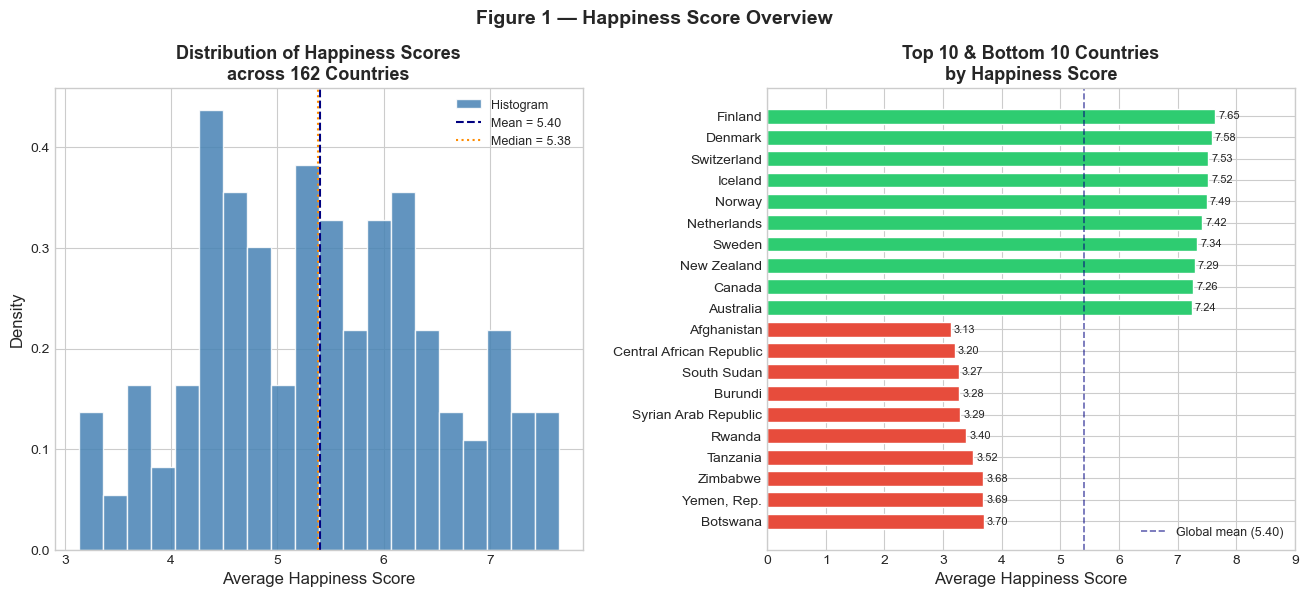

In [186]:
fig = plt.figure(figsize=(16, 6))
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)

ax1   = fig.add_subplot(gs[0])
scores = df_happiness_avg['Happiness Score'].dropna()
ax1.hist(scores, bins=20, color='steelblue', edgecolor='white', alpha=0.85,
         density=True, label='Histogram')
ax1.axvline(scores.mean(),   color='navy',       lw=1.5, ls='--',
            label=f'Mean = {scores.mean():.2f}')
ax1.axvline(scores.median(), color='darkorange',  lw=1.5, ls=':',
            label=f'Median = {scores.median():.2f}')
ax1.set_xlabel('Average Happiness Score', fontsize=12)
ax1.set_ylabel('Density', fontsize=12)
ax1.set_title('Distribution of Happiness Scores\nacross 162 Countries',
              fontsize=13, fontweight='bold')
ax1.legend(fontsize=9)

ax2      = fig.add_subplot(gs[1])
df_top   = df_happiness_avg.nlargest(10, 'Happiness Score')[['Country', 'Happiness Score']]
df_bot   = df_happiness_avg.nsmallest(10, 'Happiness Score')[['Country', 'Happiness Score']]
df_bars  = pd.concat([df_top, df_bot]).reset_index(drop=True)
bar_cols = ['#2ecc71'] * 10 + ['#e74c3c'] * 10
ax2.barh(df_bars['Country'], df_bars['Happiness Score'],
         color=bar_cols, edgecolor='white', height=0.7)
ax2.axvline(scores.mean(), color='navy', lw=1.2, ls='--', alpha=0.6,
            label=f"Global mean ({scores.mean():.2f})")
for i, (_, row) in enumerate(df_bars.iterrows()):
    ax2.text(row['Happiness Score'] + 0.05, i, f"{row['Happiness Score']:.2f}",
             va='center', fontsize=8)
ax2.invert_yaxis()
ax2.set_xlim(0, 9)
ax2.set_xlabel('Average Happiness Score', fontsize=12)
ax2.set_title('Top 10 & Bottom 10 Countries\nby Happiness Score',
              fontsize=13, fontweight='bold')
ax2.legend(fontsize=9)

plt.suptitle('Figure 1 — Happiness Score Overview', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

The distribution of average happiness scores is approximately normally distributed around the middle-to-upper range, but a long tail of low-scoring nations.
The mean (≈ 5.4) and median are very close, confirming the near-symmetry. Western Europe consistently dominates
the top 10, while Sub-Saharan Africa dominates the bottom 10.

### 3.2 Feature distributions

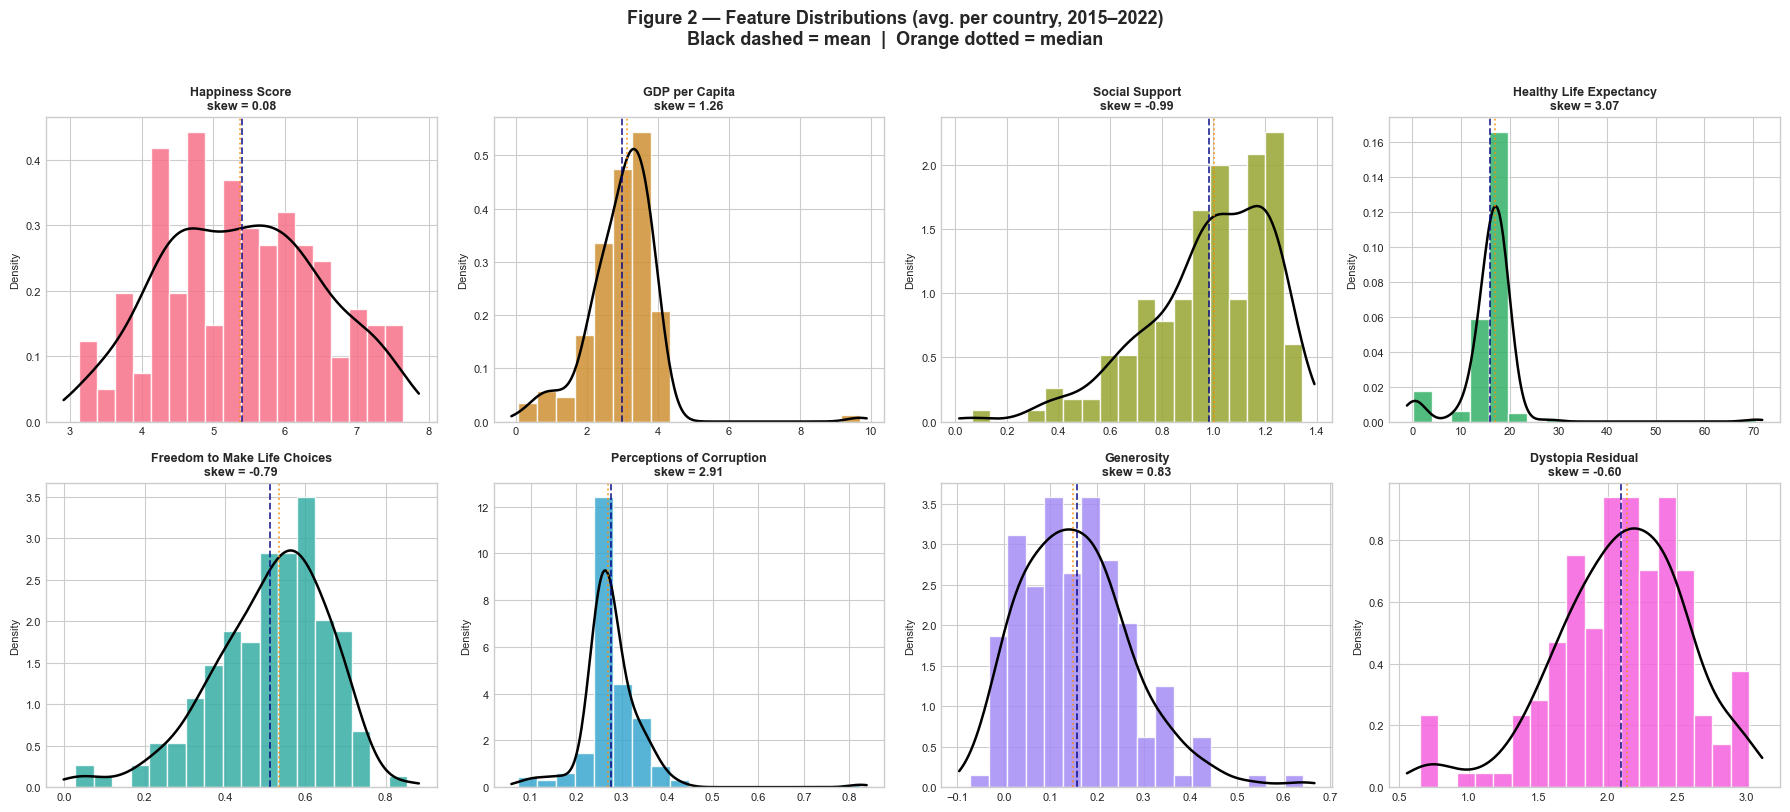

In [187]:
feat_labels = {
    'Happiness Score':           'Happiness Score',
    'GDP per Capita':            'GDP per Capita',
    'Social Support':            'Social Support',
    'Healthy Life Expectancy':   'Healthy Life Expectancy',
    'Freedom':                   'Freedom to Make Life Choices',
    'Perceptions of Corruption': 'Perceptions of Corruption',
    'Generosity':                'Generosity',
    'Dystopia Residual':         'Dystopia Residual',
}
colors_feat = sns.color_palette('husl', 8)
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, (feat, label) in enumerate(feat_labels.items()):
    ax  = axes[i]
    dat = df_happiness_avg[feat].dropna()
    ax.hist(dat, bins=18, color=colors_feat[i], edgecolor='white', alpha=0.85, density=True)
    kde_x = np.linspace(dat.min() - dat.std()*0.2, dat.max() + dat.std()*0.2, 300)
    ax.plot(kde_x, stats.gaussian_kde(dat)(kde_x), color='black', lw=1.8)
    ax.axvline(dat.mean(),   color='navy',       lw=1.3, ls='--', alpha=0.8)
    ax.axvline(dat.median(), color='darkorange',  lw=1.3, ls=':',  alpha=0.8)
    ax.set_title(f'{label}\nskew = {dat.skew():.2f}', fontsize=9, fontweight='bold')
    ax.set_ylabel('Density', fontsize=8)
    ax.tick_params(labelsize=8)

plt.suptitle(
    'Figure 2 — Feature Distributions (avg. per country, 2015–2022)\n'
    'Black dashed = mean  |  Orange dotted = median',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

A few noteworthy observations:
- **GDP per Capita** is negatively skewed — most countries have moderate GDP, but a handful of very wealthy nations pull the distribution.
- **Generosity** is close to zero for many countries and near-symmetric, suggesting it contributes relatively little to cross-country differences in happiness.
- **Perceptions of Corruption** is tightly clustered at low values for most countries, with a long right tail for highly corrupt nations.
- **Social Support** and **Freedom** are among the most normally distributed features.

### 3.3 Happiness by region

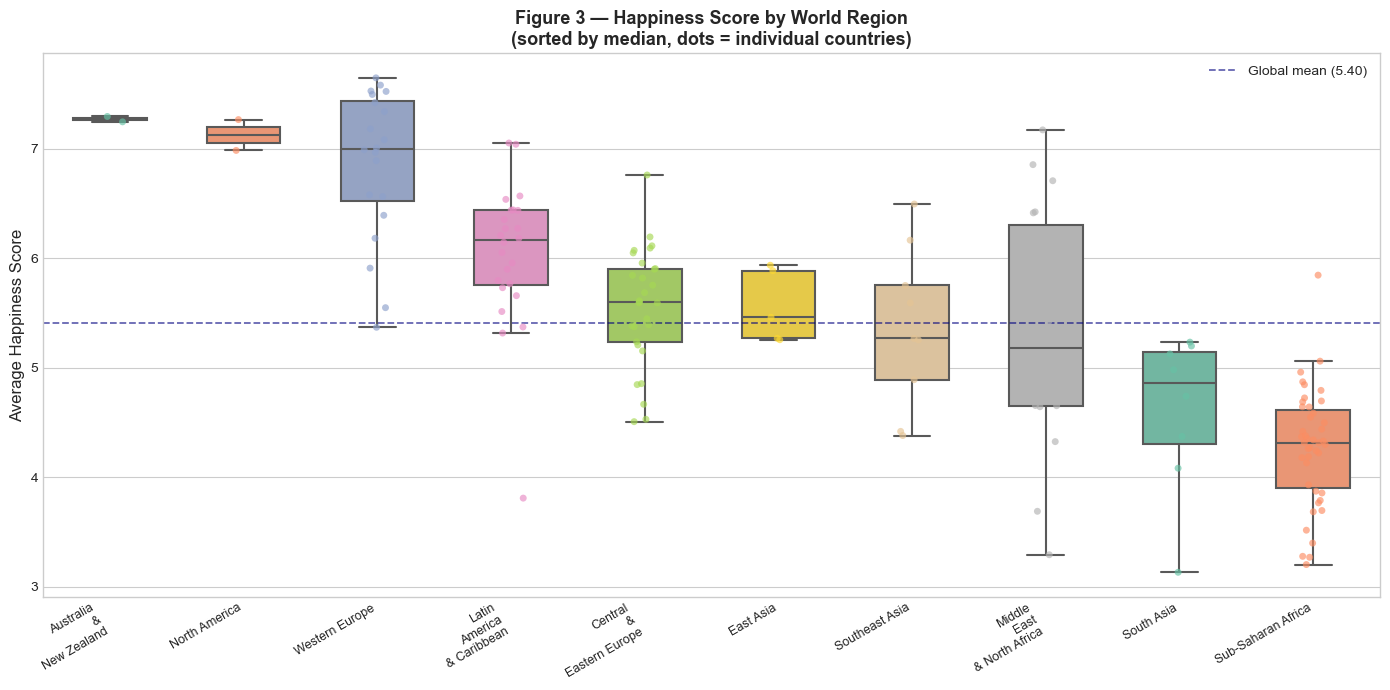

In [188]:
region_medians  = df_combined.groupby('Region')['Happiness Score'].median().sort_values(ascending=False)
ordered_regions = region_medians.index.tolist()

df_plot           = df_combined.copy()
df_plot['Region'] = pd.Categorical(df_plot['Region'], categories=ordered_regions, ordered=True)
df_plot           = df_plot.sort_values('Region')

fig, ax = plt.subplots(figsize=(14, 7))
sns.boxplot(data=df_plot, x='Region', y='Happiness Score', order=ordered_regions,
            palette='Set2', width=0.55, linewidth=1.5, fliersize=0, ax=ax)
sns.stripplot(data=df_plot, x='Region', y='Happiness Score', order=ordered_regions,
              palette='Set2', size=5, alpha=0.65, jitter=True, ax=ax)

ax.set_xticklabels(
    [r.replace(' and ', '\n& ').replace(' ', '\n', 1) if len(r) > 18 else r
     for r in ordered_regions],
    fontsize=9, rotation=30, ha='right'
)
ax.set_xlabel('')
ax.set_ylabel('Average Happiness Score', fontsize=12)
ax.set_title(
    'Figure 3 — Happiness Score by World Region\n(sorted by median, dots = individual countries)',
    fontsize=13, fontweight='bold'
)
ax.axhline(df_combined['Happiness Score'].mean(), color='navy', lw=1.3, ls='--', alpha=0.6,
           label=f"Global mean ({df_combined['Happiness Score'].mean():.2f})")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

Western Europe and Australia/New Zealand are clear outliers at the top — and crucially, these are also the regions
with the **smallest and most stable populations**. Sub-Saharan Africa and South Asia anchor the bottom.
The wide spread within some regions suggests that region alone does not fully
explain happiness.

### 3.4 Population distributions

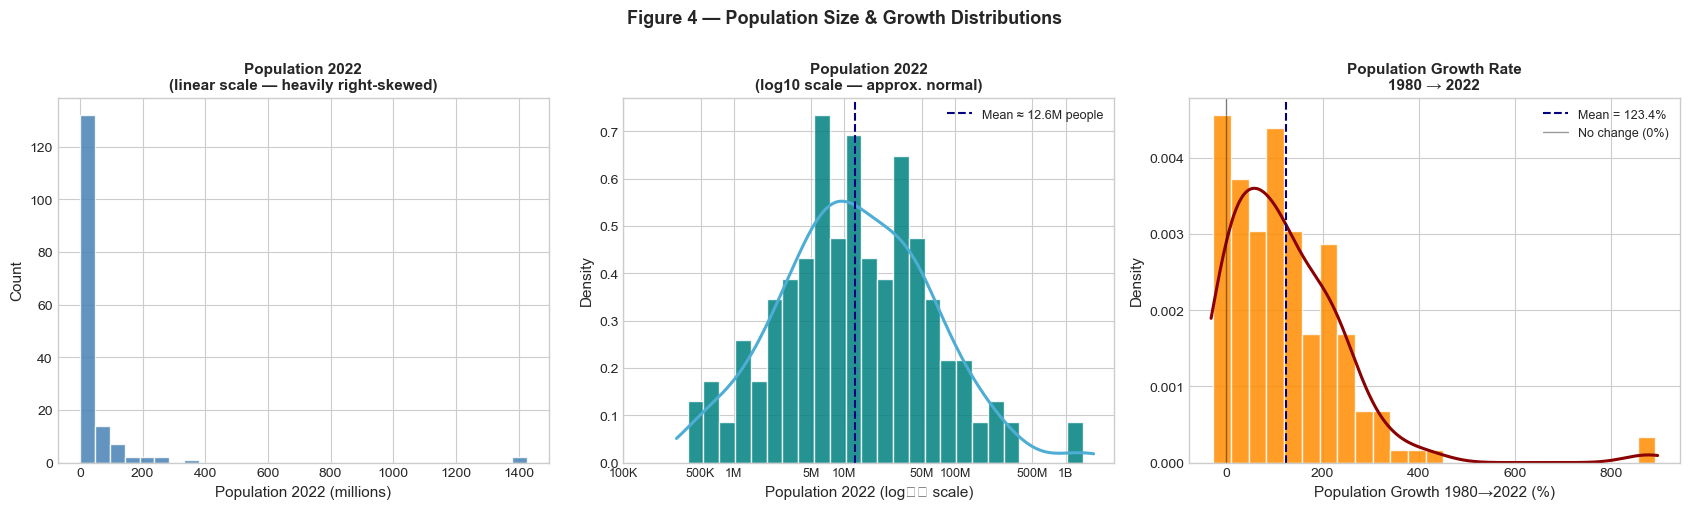

In [189]:
pop    = df_combined['Pop_2022'].dropna() / 1e6   # millions
logpop = df_combined['Log_Pop_2022'].dropna()
growth = df_combined['Pop_growth_pct'].dropna()

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Linear (shows extreme skew)
axes[0].hist(pop, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Population 2022 (millions)', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_title('Population 2022\n(linear scale — heavily right-skewed)', fontsize=11, fontweight='bold')

# Log scale
axes[1].hist(logpop, bins=25, color='teal', edgecolor='white', alpha=0.85, density=True)
kde_x = np.linspace(logpop.min() - 0.1, logpop.max() + 0.1, 300)
axes[1].plot(kde_x, stats.gaussian_kde(logpop)(kde_x), color='#4EADD4', lw=2.2)
axes[1].axvline(logpop.mean(), color='navy', lw=1.5, ls='--',
                label=f'Mean ≈ {10**logpop.mean()/1e6:.1f}M people')
axes[1].set_xticks([5, 5.7, 6, 6.7, 7, 7.7, 8, 8.7, 9])
axes[1].set_xticklabels(['100K','500K','1M','5M','10M','50M','100M','500M','1B'], fontsize=9)
axes[1].set_xlabel('Population 2022 (log₁₀ scale)', fontsize=11)
axes[1].set_ylabel('Density', fontsize=11)
axes[1].set_title('Population 2022\n(log10 scale — approx. normal)', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9)

# Growth rate
axes[2].hist(growth, bins=25, color='darkorange', edgecolor='white', alpha=0.85, density=True)
kde_x2 = np.linspace(growth.min() - 5, growth.max() + 5, 300)
axes[2].plot(kde_x2, stats.gaussian_kde(growth)(kde_x2), color='darkred', lw=2.2)
axes[2].axvline(growth.mean(), color='navy',  lw=1.5, ls='--', label=f'Mean = {growth.mean():.1f}%')
axes[2].axvline(0,             color='black', lw=1.0, ls='-',  alpha=0.4, label='No change (0%)')
axes[2].set_xlabel('Population Growth 1980→2022 (%)', fontsize=11)
axes[2].set_ylabel('Density', fontsize=11)
axes[2].set_title('Population Growth Rate\n1980 → 2022', fontsize=11, fontweight='bold')
axes[2].legend(fontsize=9)

plt.suptitle('Figure 4 — Population Size & Growth Distributions', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Population size is **extremely right-skewed on a linear scale** — a handful of very big populations (China, India, USA) makes it difficult to examine the rest.

On a log₁₀ scale the distribution becomes approximately normal.

Population growth (1980→2022) is right-skewed with a mean around +120%. A few countries have an extraordinary big growth, although this growth is not organic since it can be explained by a large amount of emigration workers in contries such as UAE, Qatar and Saudi Arabia. We later chose to filter these countries out because they obscure the image of population growth, but it's important to be aware that they also exist.

A small number of countries have actually had a decrease in population, e.g. Bulgaria, Albania, Ukraine — mostly in Eastern Europe following post-Soviet emigration.

### 3.5 Correlation matrix

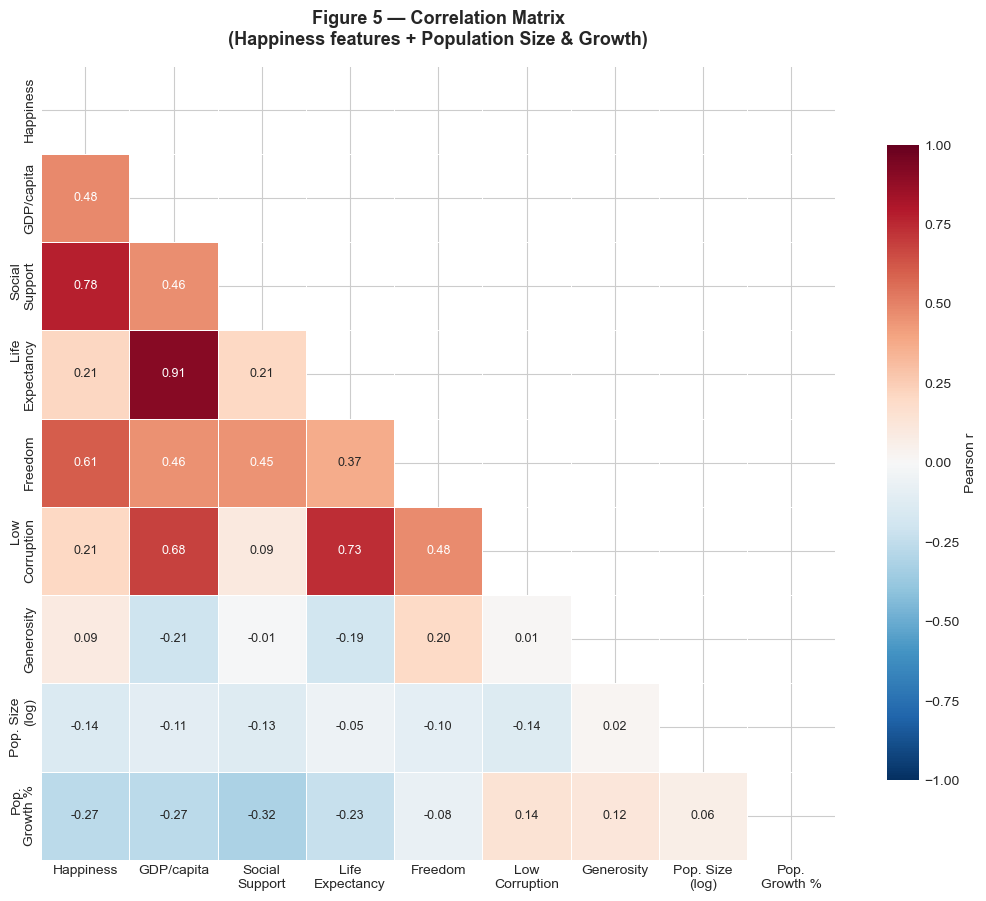

In [190]:
corr_cols = [
    'Happiness Score', 'GDP per Capita', 'Social Support',
    'Healthy Life Expectancy', 'Freedom', 'Perceptions of Corruption',
    'Generosity', 'Log_Pop_2022', 'Pop_growth_pct'
]
corr_labels = [
    'Happiness', 'GDP/capita', 'Social\nSupport', 'Life\nExpectancy',
    'Freedom', 'Low\nCorruption', 'Generosity', 'Pop. Size\n(log)', 'Pop.\nGrowth %'
]
corr_matrix = df_combined[corr_cols].corr()
mask        = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white', square=True,
    xticklabels=corr_labels, yticklabels=corr_labels,
    annot_kws={'size': 9}, ax=ax,
    cbar_kws={'shrink': 0.8, 'label': 'Pearson r'}
)
ax.set_title(
    'Figure 5 — Correlation Matrix\n(Happiness features + Population Size & Growth)',
    fontsize=13, fontweight='bold', pad=15
)
ax.tick_params(labelsize=10)
plt.tight_layout()
plt.show()

The heatmap shows how much the different features affect eachother.

- **Social Support**, **GDP per Capita** and **Freedom** are the strongest predictors of
  happiness.
- **Population size (log)** shows a weak negative correlation with happiness. So there is some 
  connection, but it doesn't seem that this is can explain the happiness of a country.
- **Population growth %** shows a stronger negative correlation with happiness. Countries
  that have grown rapidly since 1980 tend to be less happy, which may reflect rapid demographic transitions in
  lower-income regions. So it seems that the evolution of a countries population is more connected to the happiness of the country than just the population size.

### 3.6 Happiness vs. Population Size

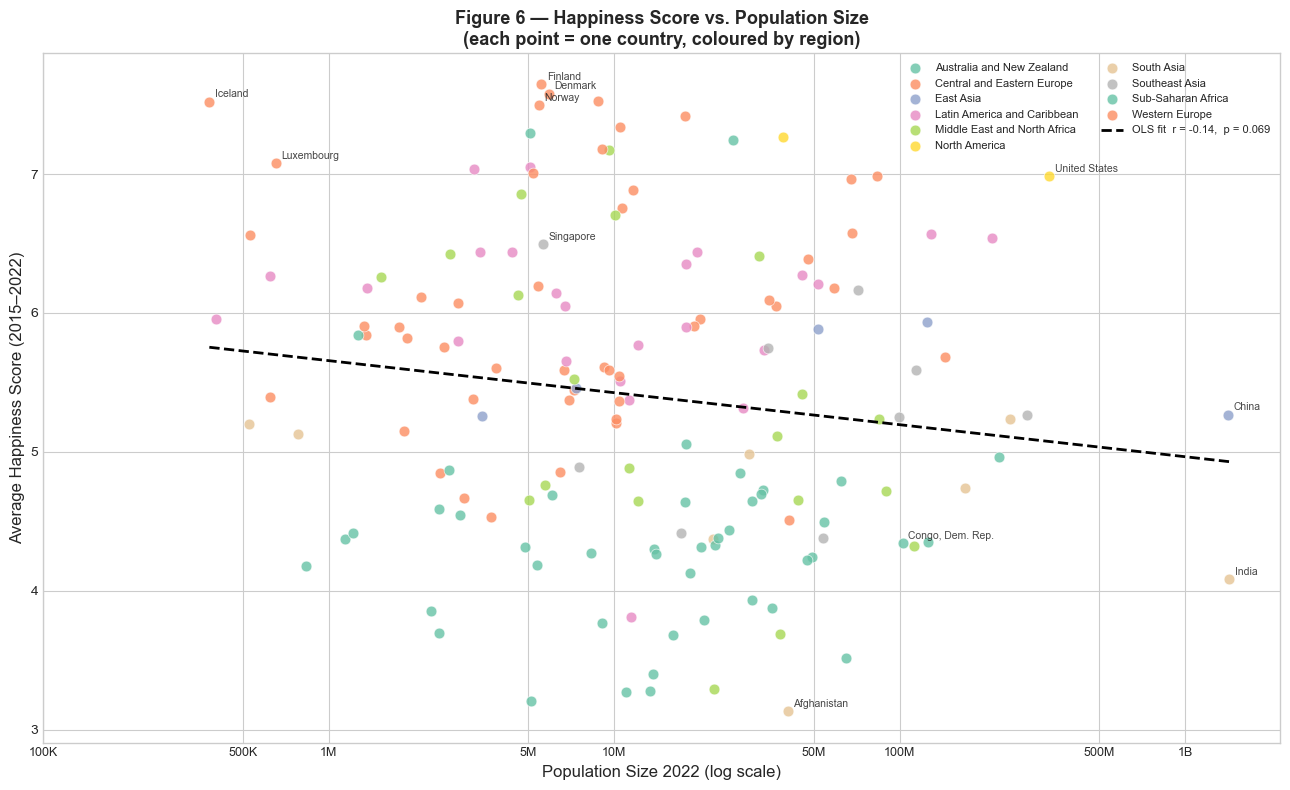

In [191]:
fig, ax = plt.subplots(figsize=(13, 8))

for region, grp in df_combined.groupby('Region'):
    ax.scatter(grp['Log_Pop_2022'], grp['Happiness Score'],
               label=region, s=60, alpha=0.8, edgecolors='white', lw=0.5)

# OLS regression line
x = df_combined['Log_Pop_2022'].dropna()
y = df_combined.loc[x.index, 'Happiness Score']
slope, intercept, r, p, se = stats.linregress(x, y)
x_line = np.linspace(x.min(), x.max(), 200)
ax.plot(x_line, intercept + slope * x_line, color='black', lw=2, ls='--',
        label=f'OLS fit  r = {r:.2f},  p = {p:.3f}')

# Annotate notable countries
notable = ['Finland', 'Denmark', 'Iceland', 'Norway', 'Afghanistan',
           'Congo, Dem. Rep.', 'China', 'India', 'United States',
           'Luxembourg', 'Singapore']
for _, row in df_combined[df_combined['Country'].isin(notable)].iterrows():
    ax.annotate(row['Country'],
                (row['Log_Pop_2022'], row['Happiness Score']),
                fontsize=7.5, xytext=(4, 3), textcoords='offset points', alpha=0.85)

ax.set_xticks([5, 5.7, 6, 6.7, 7, 7.7, 8, 8.7, 9])
ax.set_xticklabels(['100K', '500K', '1M', '5M', '10M', '50M', '100M', '500M', '1B'], fontsize=9)
ax.set_xlabel('Population Size 2022 (log scale)', fontsize=12)
ax.set_ylabel('Average Happiness Score (2015–2022)', fontsize=12)
ax.set_title(
    'Figure 6 — Happiness Score vs. Population Size\n'
    '(each point = one country, coloured by region)',
    fontsize=13, fontweight='bold'
)
ax.legend(fontsize=8, loc='upper right', ncol=2)
plt.tight_layout()
plt.show()

The scatter plot shows a small downward trend — larger populations tend to score slightly lower on happiness.
However, the relationship is far from convincing, since several large countries (USA, Germany) score well, while
several small countries (e.g. in Sub-Saharan Africa) score poorly. The negative slope is largely driven by
**region**: African countries are both populous-growth nations and low-happiness nations, while Western European
countries are small and happy.

### 3.7 Happiness vs. Population Growth

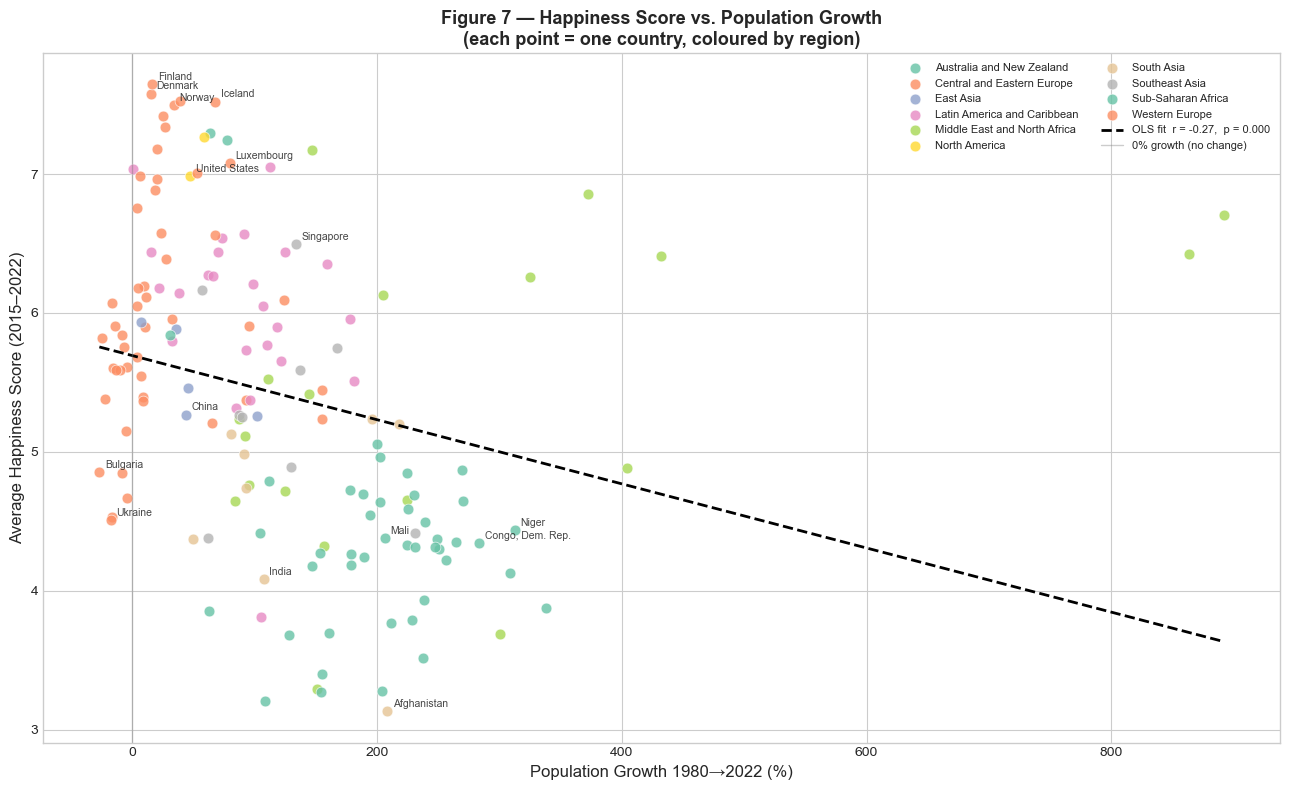

In [192]:
fig, ax = plt.subplots(figsize=(13, 8))

for region, grp in df_combined.groupby('Region'):
    ax.scatter(grp['Pop_growth_pct'], grp['Happiness Score'],
               label=region, s=60, alpha=0.8, edgecolors='white', lw=0.5)

# OLS regression line
x = df_combined['Pop_growth_pct'].dropna()
y = df_combined.loc[x.index, 'Happiness Score']
slope, intercept, r, p, se = stats.linregress(x, y)
x_line = np.linspace(x.min(), x.max(), 200)
ax.plot(x_line, intercept + slope * x_line, color='black', lw=2, ls='--',
        label=f'OLS fit  r = {r:.2f},  p = {p:.3f}')

# Annotate notable countries
notable = ['Finland', 'Denmark', 'Iceland', 'Norway', 'Afghanistan',
           'Congo, Dem. Rep.', 'China', 'India', 'United States',
           'Luxembourg', 'Singapore', 'Ukraine', 'Bulgaria', 'Niger', 'Mali']
for _, row in df_combined[df_combined['Country'].isin(notable)].iterrows():
    ax.annotate(row['Country'],
                (row['Pop_growth_pct'], row['Happiness Score']),
                fontsize=7.5, xytext=(4, 3), textcoords='offset points', alpha=0.85)

ax.axvline(0, color='grey', lw=1, ls='-', alpha=0.4, label='0% growth (no change)')
ax.set_xlabel('Population Growth 1980→2022 (%)', fontsize=12)
ax.set_ylabel('Average Happiness Score (2015–2022)', fontsize=12)
ax.set_title(
    'Figure 7 — Happiness Score vs. Population Growth\n'
    '(each point = one country, coloured by region)',
    fontsize=13, fontweight='bold'
)
ax.legend(fontsize=8, loc='upper right', ncol=2)
plt.tight_layout()
plt.show()

The chart above includes all countries. However, as mentioned earlier three outliers disturbs the regression line without adding meaningful insight: the United Arab Emirates and Qatar show 800–900% population growth since 1980, but this growth is driven almost entirely by labour migration rather than by births. 

It is hard to decide wether to include them or not, since population in all countries are affected by factors such as migration workers etc.
In the next plot we try to exclude them to get a picture of the correlation without them disturbing.

Countries included in the plot: 160  (countries removed: ['United Arab Emirates', 'Qatar'])


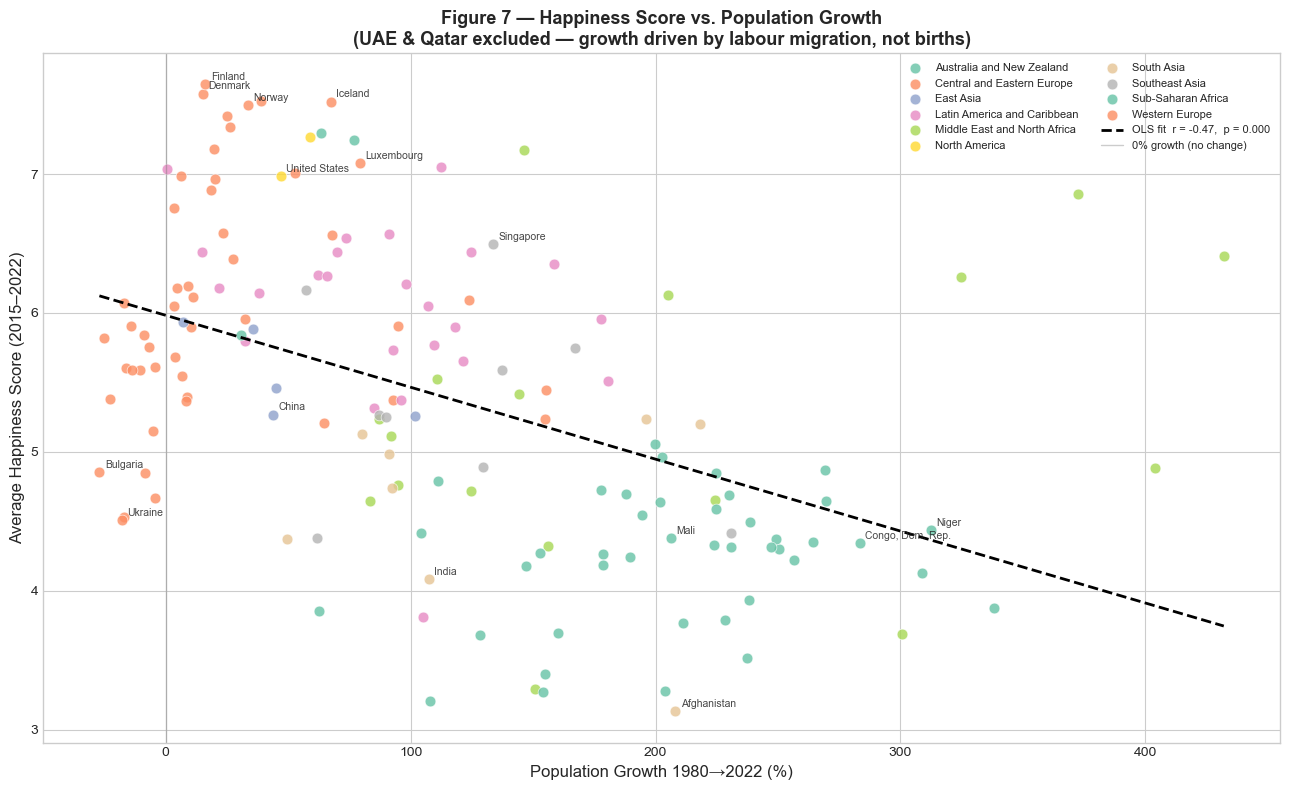

In [211]:
# UAE, Qatar og Saudi Arabia is removed
migration_outliers = ['United Arab Emirates', 'Qatar']
df_plot = df_combined[~df_combined['Country'].isin(migration_outliers)].copy()

print(f"Countries included in the plot: {len(df_plot)}  (countries removed: {migration_outliers})")

fig, ax = plt.subplots(figsize=(13, 8))

for region, grp in df_plot.groupby('Region'):
    ax.scatter(grp['Pop_growth_pct'], grp['Happiness Score'],
               label=region, s=60, alpha=0.8, edgecolors='white', lw=0.5)

# OLS regression line
x = df_plot['Pop_growth_pct'].dropna()
y = df_plot.loc[x.index, 'Happiness Score']
slope, intercept, r, p, se = stats.linregress(x, y)
x_line = np.linspace(x.min(), x.max(), 200)
ax.plot(x_line, intercept + slope * x_line, color='black', lw=2, ls='--',
        label=f'OLS fit  r = {r:.2f},  p = {p:.3f}')

# Annotate notable countries
notable = ['Finland', 'Denmark', 'Iceland', 'Norway', 'Afghanistan',
           'Congo, Dem. Rep.', 'China', 'India', 'United States',
           'Luxembourg', 'Singapore', 'Ukraine', 'Bulgaria', 'Niger', 'Mali']
for _, row in df_plot[df_plot['Country'].isin(notable)].iterrows():
    ax.annotate(row['Country'],
                (row['Pop_growth_pct'], row['Happiness Score']),
                fontsize=7.5, xytext=(4, 3), textcoords='offset points', alpha=0.85)

ax.axvline(0, color='grey', lw=1, ls='-', alpha=0.4, label='0% growth (no change)')
ax.set_xlabel('Population Growth 1980→2022 (%)', fontsize=12)
ax.set_ylabel('Average Happiness Score (2015–2022)', fontsize=12)
ax.set_title(
    'Figure 7 — Happiness Score vs. Population Growth\n'
    '(UAE & Qatar excluded — growth driven by labour migration, not births)',
    fontsize=13, fontweight='bold'
)
ax.legend(fontsize=8, loc='upper right', ncol=2)
plt.tight_layout()
plt.show()

After removing the outliers, the correlation is a bit more significant. There is a pattern of countries being a bit less happy if they have a big population growth.

---
## 4. Genre
<a id='4-genre'></a>

### 4.1 Choice of genre

**Genre:** Magazine Style (Segel & Heer, 2010)

We chose Magazine Style because our story requires multiple visualizations that each shows a different
aspect of the same argument. Text and charts are interspersed: each paragraph sets up a claim, the chart
tests it, and the next paragraph interprets the result. The reader follows a clear linear path from
observation to conclusion, which maps naturally to a scrollable long-form web page.

The story also follows a **Martini Glass** structure: sections 1–4 are author-driven (the reader
follows a fixed sequence), while section 5 (the feature explorer) opens into reader-driven exploration
where the reader chooses which variable to examine.

---

### 4.2 Visual Narrative (Figure 7, Segel & Heer)

| Category | Tools used | Justification |
|----------|-----------|---------------|
| **Visual Structuring** | Establishing Shot, Consistent Visual Platform | The choropleth map opens the story with a global overview. All five plots share the same colour palette and region colours, giving the reader a stable visual reference throughout. |
| **Highlighting** | Colour Encoding, Hover Highlighting | Regions are consistently colour-coded across all scatter plots. Hover tooltips surface key statistics on demand without cluttering the chart. |
| **Transition Guidance** | Continuity Editing | The same region colours carry over from plot to plot, allowing the reader to track the same groups across different chart types without re-learning the legend. |

### 4.3 Narrative Structure (Figure 7, Segel & Heer)

| Category | Tools used | Justification |
|----------|-----------|---------------|
| **Ordering** | Linear (sections 1–4), then Random Access (section 5) | The first four sections must be read in order to build the argument. Section 5 is open-ended: the dropdown lets the reader explore any feature freely. |
| **Interactivity** | Hover Highlighting, Filtering/Dropdown | Hover is used on all five plots. The feature explorer uses a dropdown to switch between variables, giving the reader agency without overwhelming them. |
| **Messaging** | Captions, Introductory Text, Summary | Every figure has a caption. Each section opens with explanatory text that frames the chart. The conclusion synthesises the findings into a single takeaway. |

---
## 5. Visualizations
<a id='5-visualizations'></a>

The five visualizations below are the ones used on the website. They are all built with Plotly for interactivity.

A shared colour palette is defined once and reused across all plots and on the website for visual consistency.

In [194]:
SITE_COLOURS = {
    'primary':    '#2C5F8A',   # Deep steel blue     — headings, navbar, key elements
    'accent':     '#4EADD4',   # Light sky blue       — links, hover states, highlights
    'background': '#F7F9FB',   # Off-white blue tint  — page background
    'text':       '#1A2B3C',   # Near-black blue tone — body text
    'highlight':  '#E8C84A',   # Warm yellow          — call-to-action, key numbers
    'white':      '#FFFFFF',   # Pure white           — cards, plot backgrounds
    'muted':      '#8FA8BF',   # Muted blue-grey      — captions, secondary text
    'low':        '#c0392b',   # Dark red             — low happiness (matches map)
}

REGION_COLOURS = {
    'Western Europe':               '#2C5F8A',   # Primary blue
    'Central and Eastern Europe':   '#4EADD4',   # Accent blue
    'North America':                '#3A8C6E',   # Teal green
    'Australia and New Zealand':    '#52B788',   # Mint green
    'Latin America and Caribbean':  '#E8C84A',   # Warm yellow (highlight)
    'East Asia':                    '#D4845A',   # Warm terracotta
    'Southeast Asia':               '#C96B6B',   # Muted coral
    'South Asia':                   '#8B5E8A',   # Muted purple
    'Middle East and North Africa': '#B87333',   # Bronze
    'Sub-Saharan Africa':           '#6B4C3B',   # Dark brown
}



### 5.1 Choropleth World Map — *Where in the world are people happy?*

**Type:** Interactive choropleth map (Plotly)

**Purpose:** Opens the data story with a global overview. The reader immediately sees the overall pattern — Northern and Western Europe in deep blue, Africa and South Asia in warm red. It raises the question: what do the happiest countries have in common?

**Justification:** A map is the natural *establishing shot* (Segel & Heer, 2010) for a story about countries. It is universally readable and visually striking. Interactivity lets the reader explore any country by hovering.

In [195]:
# ISO-3 country code lookup — needed for Plotly choropleth
ISO3_MAP = {
    'Afghanistan': 'AFG', 'Albania': 'ALB', 'Algeria': 'DZA', 'Angola': 'AGO',
    'Argentina': 'ARG', 'Armenia': 'ARM', 'Australia': 'AUS', 'Austria': 'AUT',
    'Azerbaijan': 'AZE', 'Bahrain': 'BHR', 'Bangladesh': 'BGD', 'Belarus': 'BLR',
    'Belgium': 'BEL', 'Benin': 'BEN', 'Bolivia': 'BOL', 'Bosnia and Herzegovina': 'BIH',
    'Botswana': 'BWA', 'Brazil': 'BRA', 'Bulgaria': 'BGR', 'Burkina Faso': 'BFA',
    'Burundi': 'BDI', 'Cambodia': 'KHM', 'Cameroon': 'CMR', 'Canada': 'CAN',
    'Central African Republic': 'CAF', 'Chad': 'TCD', 'Chile': 'CHL', 'China': 'CHN',
    'Colombia': 'COL', 'Comoros': 'COM', 'Congo, Dem. Rep.': 'COD', 'Congo, Rep.': 'COG',
    'Costa Rica': 'CRI', 'Croatia': 'HRV', 'Czechia': 'CZE', 'Denmark': 'DNK',
    'Dominican Republic': 'DOM', 'Ecuador': 'ECU', 'Egypt, Arab Rep.': 'EGY',
    'El Salvador': 'SLV', 'Estonia': 'EST', 'Eswatini': 'SWZ', 'Ethiopia': 'ETH',
    'Finland': 'FIN', 'France': 'FRA', 'Gabon': 'GAB', 'Gambia, The': 'GMB',
    'Georgia': 'GEO', 'Germany': 'DEU', 'Ghana': 'GHA', 'Greece': 'GRC',
    'Guatemala': 'GTM', 'Guinea': 'GIN', 'Haiti': 'HTI', 'Honduras': 'HND',
    'Hong Kong SAR, China': 'HKG', 'Hungary': 'HUN', 'Iceland': 'ISL', 'India': 'IND',
    'Indonesia': 'IDN', 'Iran, Islamic Rep.': 'IRN', 'Iraq': 'IRQ', 'Ireland': 'IRL',
    'Israel': 'ISR', 'Italy': 'ITA', 'Jamaica': 'JAM', 'Japan': 'JPN', 'Jordan': 'JOR',
    'Kazakhstan': 'KAZ', 'Kenya': 'KEN', 'Kosovo': 'XKX', 'Kuwait': 'KWT',
    'Kyrgyz Republic': 'KGZ', 'Lao PDR': 'LAO', 'Latvia': 'LVA', 'Lebanon': 'LBN',
    'Lesotho': 'LSO', 'Liberia': 'LBR', 'Lithuania': 'LTU', 'Luxembourg': 'LUX',
    'Madagascar': 'MDG', 'Malawi': 'MWI', 'Malaysia': 'MYS', 'Mali': 'MLI',
    'Malta': 'MLT', 'Mauritania': 'MRT', 'Mauritius': 'MUS', 'Mexico': 'MEX',
    'Moldova': 'MDA', 'Mongolia': 'MNG', 'Montenegro': 'MNE', 'Morocco': 'MAR',
    'Mozambique': 'MOZ', 'Myanmar': 'MMR', 'Namibia': 'NAM', 'Nepal': 'NPL',
    'Netherlands': 'NLD', 'New Zealand': 'NZL', 'Nicaragua': 'NIC', 'Niger': 'NER',
    'Nigeria': 'NGA', 'North Macedonia': 'MKD', 'Norway': 'NOR', 'Oman': 'OMN',
    'Pakistan': 'PAK', 'Panama': 'PAN', 'Paraguay': 'PRY', 'Peru': 'PER',
    'Philippines': 'PHL', 'Poland': 'POL', 'Portugal': 'PRT', 'Puerto Rico (US)': 'PRI',
    'Qatar': 'QAT', 'Romania': 'ROU', 'Russian Federation': 'RUS', 'Rwanda': 'RWA',
    'Saudi Arabia': 'SAU', 'Senegal': 'SEN', 'Serbia': 'SRB', 'Sierra Leone': 'SLE',
    'Singapore': 'SGP', 'Slovak Republic': 'SVK', 'Slovenia': 'SVN',
    'Somalia, Fed. Rep.': 'SOM', 'South Africa': 'ZAF', 'South Sudan': 'SSD',
    'Spain': 'ESP', 'Sri Lanka': 'LKA', 'Sweden': 'SWE', 'Switzerland': 'CHE',
    'Syrian Arab Republic': 'SYR', 'Tanzania': 'TZA', 'Thailand': 'THA', 'Togo': 'TGO',
    'Trinidad and Tobago': 'TTO', 'Tunisia': 'TUN', 'Turkiye': 'TUR',
    'Turkmenistan': 'TKM', 'Uganda': 'UGA', 'Ukraine': 'UKR',
    'United Arab Emirates': 'ARE', 'United Kingdom': 'GBR', 'United States': 'USA',
    'Uruguay': 'URY', 'Uzbekistan': 'UZB', 'Venezuela, RB': 'VEN', 'Viet Nam': 'VNM',
    'West Bank and Gaza': 'PSE', 'Yemen, Rep.': 'YEM', 'Zambia': 'ZMB',
    'Zimbabwe': 'ZWE', "Cote d'Ivoire": 'CIV',
}

df_map = df_happiness_avg.copy()
df_map['ISO3'] = df_map['Country'].map(ISO3_MAP)
df_map = df_map.dropna(subset=['ISO3'])
df_map['Happiness Score'] = df_map['Happiness Score'].round(2)
df_map['GDP per Capita']  = df_map['GDP per Capita'].round(2)
df_map['Social Support']  = df_map['Social Support'].round(2)

fig1 = px.choropleth(
    df_map,
    locations='ISO3',
    color='Happiness Score',
    hover_name='Country',
    hover_data={
        'ISO3': False,
        'Happiness Score': True,
        'Region': True,
    },
    color_continuous_scale=[
        (0.0, '#c0392b'),
        (0.3, '#e07b4a'),
        (0.5, '#F7F9FB'),
        (0.7, '#4EADD4'),
        (1.0, '#2C5F8A'),
    ],
    range_color=(2.5, 8.0),
    labels={'Happiness Score': 'Happiness Score'},
)
fig1.update_layout(
    geo=dict(
        showframe=False,
        showcoastlines=True,
        coastlinecolor='white',
        showland=True,
        landcolor='#f0f0f0',
        showocean=True,
        oceancolor='#e8f4f8',
        projection_type='natural earth',
        lataxis=dict(range=[-80, 80], showgrid=False),
        lonaxis=dict(range=[-180, 180], showgrid=False),
    ),
    coloraxis_colorbar=dict(
        title='Happiness<br>Score',
        tickvals=[3, 4, 5, 6, 7, 8],
        thickness=15, len=0.6,
    ),
    dragmode='pan',
    margin=dict(l=0, r=0, t=10, b=10),
    height=600,
    paper_bgcolor='#FFFFFF',
)

fig1.show()
fig1.write_html('/Users/fridafrandsen/Desktop/Social Data analysis and visualizaton/Final Project/fridapfrandsen.github.io/plot1_choropleth.html', include_plotlyjs='cdn')

### 5.2 Top 10 / Bottom 10 Bar Chart — *The happiest countries are strikingly small*

**Type:** Interactive horizontal bar chart (Plotly)

**Purpose:** Zooms in on the concrete countries. The reader sees Finland, Denmark, Iceland, Norway in the top — and it becomes immediately clear that the top is dominated by small nations.

**Justification:** The bar chart plants the hypothesis explicitly without requiring much explanation. Hover tooltips show population size, so the reader can verify the size pattern themselves.

In [205]:
df_combined['Pop_2022_M'] = (df_combined['Pop_2022'] / 1e6).round(2)

top10 = df_combined.nlargest(10,  'Happiness Score').copy()
bot10 = df_combined.nsmallest(10, 'Happiness Score').copy()
top10['Group'] = 'Top 10: Happiest'
bot10['Group'] = 'Bottom 10: Least Happy'

df_bars = pd.concat([bot10, top10]).reset_index(drop=True)

fig2 = go.Figure()

for group, colour in [
    ('Bottom 10: Least Happy', SITE_COLOURS['low']),
    ('Top 10: Happiest',       SITE_COLOURS['primary']),
]:
    subset = df_bars[df_bars['Group'] == group].sort_values(
        'Happiness Score', ascending=(group == 'Top 10: Happiest')
    )
    fig2.add_trace(go.Bar(
        x=subset['Happiness Score'],
        y=subset['Country'],
        orientation='h',
        name=group,
        marker_color=colour,
        customdata=np.stack([
            subset['Pop_2022_M'],
            subset['Region'],
        ], axis=-1),
        hovertemplate=(
            '<b>%{y}</b><br>'
            'Happiness Score: <b>%{x:.2f}</b><br>'
            'Population (2022): <b>%{customdata[0]:.1f}M</b><br>'
            'Region: %{customdata[1]}<br>'
            '<extra></extra>'
        ),
        text=subset['Happiness Score'].round(2),
        textposition='outside',
        textfont=dict(size=11, color=SITE_COLOURS['text']),
    ))

global_mean = df_combined['Happiness Score'].mean()
fig2.add_vline(
    x=global_mean,
    line_dash='dash',
    line_color=SITE_COLOURS['muted'],
    line_width=1.5,
    annotation_text=f'Global mean ({global_mean:.2f})',
    annotation_position='top',
    annotation_font_size=11,
    annotation_font_color=SITE_COLOURS['muted'],
)

fig2.update_layout(
    xaxis=dict(title='Average Happiness Score', range=[0, 9.2],
               showgrid=True, gridcolor='#eeeeee', color=SITE_COLOURS['text']),
    yaxis=dict(title='', autorange='reversed', color=SITE_COLOURS['text']),
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1,
                font=dict(color=SITE_COLOURS['text'])),
    plot_bgcolor='#FFFFFF',
    paper_bgcolor='#FFFFFF',
    height=580,
    margin=dict(l=160, r=40, t=20, b=60),
    font=dict(family='Arial', size=12, color=SITE_COLOURS['text']),
)

fig2.show()
fig2.write_html('/Users/fridafrandsen/Desktop/Social Data analysis and visualizaton/Final Project/fridapfrandsen.github.io/plot2_top_bottom.html', include_plotlyjs='cdn')

### 5.3 Scatter Plot — *Is there a pattern between size and happiness?*

**Type:** Interactive scatter plot (Plotly)

**Purpose:** Tests the hypothesis formally. All 162 countries are plotted and the regression line shows the negative relationship. Colour by region lets the reader see that the pattern is partly driven by geography.

**Justification:** The log scale on the x-axis is essential — population spans from 100K to 1.4B, which makes a linear axis unreadable. The x-axis ticks are labelled with readable values (1M, 50M, etc.) rather than raw log numbers.

In [209]:
# OLS regression line
x_vals = df_combined['Log_Pop_2022'].dropna()
y_vals = df_combined.loc[x_vals.index, 'Happiness Score']
slope, intercept, r, p, _ = stats.linregress(x_vals, y_vals)
x_line = np.linspace(x_vals.min(), x_vals.max(), 200)
y_line = intercept + slope * x_line

fig3 = go.Figure()

for region in sorted(df_combined['Region'].unique()):
    grp = df_combined[df_combined['Region'] == region]
    fig3.add_trace(go.Scatter(
        x=grp['Log_Pop_2022'],
        y=grp['Happiness Score'],
        mode='markers',
        name=region,
        marker=dict(
            color=REGION_COLOURS.get(region, SITE_COLOURS['muted']),
            size=9, opacity=0.85,
            line=dict(width=0.8, color='white'),
        ),
        customdata=np.stack([
            grp['Country'],
            (grp['Pop_2022'] / 1e6).round(2),
            grp['Pop_growth_pct'],
        ], axis=-1),
        hovertemplate=(
            '<b>%{customdata[0]}</b><br>'
            'Happiness Score: <b>%{y:.2f}</b><br>'
            'Population (2022): <b>%{customdata[1]:.1f}M</b><br>'
            'Pop. Growth since 1980: <b>%{customdata[2]:.1f}M</b><br>'
            '<extra></extra>'
        ),
    ))

fig3.add_trace(go.Scatter(
    x=x_line, y=y_line, mode='lines',
    name=f'OLS trend  (r = {r:.2f}, p = {p:.3f})',
    line=dict(color=SITE_COLOURS['text'], width=2, dash='dash'),
    hoverinfo='skip',
))

tickvals   = [5, 5.699, 6, 6.699, 7, 7.699, 8, 8.699, 9]
ticklabels = ['100K', '500K', '1M', '5M', '10M', '50M', '100M', '500M', '1B']

fig3.update_layout(
    xaxis=dict(
        title='Population Size 2022 (log scale)',
        tickvals=tickvals, ticktext=ticklabels,
        showgrid=True, gridcolor='#eeeeee',
        color=SITE_COLOURS['text'],
    ),
    yaxis=dict(
        title='Average Happiness Score (2015–2022)',
        showgrid=True, gridcolor='#eeeeee',
        range=[2, 8.5],
        color=SITE_COLOURS['text'],
    ),
    legend=dict(
        title='Region', x=1.01, y=1,
        font=dict(size=11, color=SITE_COLOURS['text']),
        title_font=dict(color=SITE_COLOURS['text']),
    ),
    plot_bgcolor='#FFFFFF',
    paper_bgcolor='#FFFFFF',
    height=560,
    margin=dict(l=70, r=200, t=20, b=70),
    font=dict(family='Arial', size=12, color=SITE_COLOURS['text']),
)

fig3.show()
fig3.write_html('/Users/fridafrandsen/Desktop/Social Data analysis and visualizaton/Final Project/fridapfrandsen.github.io/plot3_scatter_size.html', include_plotlyjs='cdn')

### 5.4 Scatter Plot — *It's not the size but the evolution in size*

**Type:** Interactive scatter plot (Plotly)

**Purpose:** Show our finding: countries that have grown fastest since 1980 tend to be less happy.

**Justification:** United Arab Emirates and Qatar are excluded from this plot because their extreme growth (800–900%) is driven almost entirely by labour migration, not organic population growth. This is clearly noted in the plot itself.

In [210]:
# Exclude UAE, Qatar, Saudi Arabia — growth driven by labour migration, not births
MIGRATION_OUTLIERS = ['United Arab Emirates', 'Qatar']
df_growth = df_combined[~df_combined['Country'].isin(MIGRATION_OUTLIERS)].copy()

# OLS on filtered data
xg = df_growth['Pop_growth_pct'].dropna()
yg = df_growth.loc[xg.index, 'Happiness Score']
slope_g, intercept_g, r_g, p_g, _ = stats.linregress(xg, yg)
xg_line = np.linspace(xg.min(), xg.max(), 200)
yg_line = intercept_g + slope_g * xg_line

fig4 = go.Figure()

for region in sorted(df_growth['Region'].unique()):
    grp = df_growth[df_growth['Region'] == region]
    fig4.add_trace(go.Scatter(
        x=grp['Pop_growth_pct'],
        y=grp['Happiness Score'],
        mode='markers',
        name=region,
        marker=dict(
            color=REGION_COLOURS.get(region, SITE_COLOURS['muted']),
            size=9, opacity=0.85,
            line=dict(width=0.8, color='white'),
        ),
        customdata=np.stack([
            grp['Country'],
            (grp['Pop_2022'] / 1e6).round(2),
            (grp['Pop_1980'] / 1e6).round(2),
            grp['GDP per Capita'],
        ], axis=-1),
        hovertemplate=(
            '<b>%{customdata[0]}</b><br>'
            'Happiness Score: <b>%{y:.2f}</b><br>'
            'Pop. Growth 1980→2022: <b>%{x:.1f}%</b><br>'
            'Population 1980: %{customdata[2]:.1f}M → 2022: %{customdata[1]:.1f}M<br>'
            'GDP per Capita: %{customdata[3]:.2f}<br>'
            '<extra></extra>'
        ),
    ))

fig4.add_trace(go.Scatter(
    x=xg_line, y=yg_line, mode='lines',
    name=f'OLS trend  (r = {r_g:.2f}, p = {p_g:.3f})',
    line=dict(color=SITE_COLOURS['text'], width=2, dash='dash'),
    hoverinfo='skip',
))

fig4.add_vline(
    x=0,
    line_color=SITE_COLOURS['muted'],
    line_width=1.2,
    line_dash='dot',
    annotation_text='No growth',
    annotation_position='top left',
    annotation_font_size=10,
    annotation_font_color=SITE_COLOURS['muted'],
)
fig4.add_annotation(
    x=0.99, y=0.02, xref='paper', yref='paper',
    text='<i>UAE & Qatar excluded<br>(growth driven by labour migration)</i>',
    showarrow=False,
    font=dict(size=10, color=SITE_COLOURS['muted']),
    align='right', xanchor='right',
)

fig4.update_layout(
    xaxis=dict(
        title='Population Growth 1980 → 2022 (%)',
        showgrid=True, gridcolor='#eeeeee',
        color=SITE_COLOURS['text'],
    ),
    yaxis=dict(
        title='Average Happiness Score (2015–2022)',
        showgrid=True, gridcolor='#eeeeee',
        range=[2, 8.5],
        color=SITE_COLOURS['text'],
    ),
    legend=dict(
        title='Region', x=1.01, y=1,
        font=dict(size=11, color=SITE_COLOURS['text']),
        title_font=dict(color=SITE_COLOURS['text']),
    ),
    plot_bgcolor='#FFFFFF',
    paper_bgcolor='#FFFFFF',
    height=560,
    margin=dict(l=70, r=200, t=20, b=70),
    font=dict(family='Arial', size=12, color=SITE_COLOURS['text']),
)

fig4.show()
fig4.write_html('/Users/fridafrandsen/Desktop/Social Data analysis and visualizaton/Final Project/fridapfrandsen.github.io/plot4_scatter_growth.html', include_plotlyjs='cdn')

### 5.5 Interactive Feature Explorer — *What actually drives happiness?*

**Type:** Interactive scatter plot with dropdown (Plotly)

**Purpose:** Closes the data story by showing the bigger picture. Having established that population size and growth have a weak negative relationship with happiness, this plot lets the reader explore what actually explains happiness — GDP, social support, freedom, life expectancy, and more. Each feature can be selected from a dropdown menu, and the regression line and correlation coefficient update automatically.

**Justification:** Population growth explains some of the variation in happiness, but the correlation matrix showed that GDP per Capita, Social Support, and Freedom are far stronger predictors. This plot makes that contrast explorable, inviting the reader to reach the conclusion themselves rather than being told. It also serves as a natural discussion point: the countries that score low on happiness tend to have high population growth and low GDP/social support — so which is cause and which is effect?

In [199]:
features = [
    ('GDP per Capita',           'GDP per Capita'),
    ('Social Support',           'Social Support'),
    ('Healthy Life Expectancy',  'Healthy Life Expectancy (years)'),
    ('Freedom',                  'Freedom to Make Life Choices'),
    ('Perceptions of Corruption','Perceptions of Corruption'),
    ('Generosity',               'Generosity'),
    ('Log_Pop_2022',             'Population Size 2022 (log scale)'),
    ('Pop_growth_pct',           'Population Growth 1980→2022 (%)'),
]

df_plot = df_combined.copy()
df_plot['Pop_2022_M'] = (df_plot['Pop_2022'] / 1e6).round(2)

def ols_line(feature):
    x = df_plot[feature].dropna()
    y = df_plot.loc[x.index, 'Happiness Score']
    slope, intercept, r, p, _ = stats.linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 200)
    return x_line, intercept + slope * x_line, r, p

fig5 = go.Figure()

regions = sorted(df_plot['Region'].unique())
n_features = len(features)
n_regions  = len(regions)

for f_idx, (feat, feat_label) in enumerate(features):
    x_line, y_line, r, p = ols_line(feat)
    is_first = (f_idx == 0)

    for region in regions:
        grp = df_plot[df_plot['Region'] == region].dropna(subset=[feat])

        if feat == 'Log_Pop_2022':
            x_hover = '10^%{x:.2f} people'
        elif feat == 'Pop_growth_pct':
            x_hover = '%{x:.1f}%'
        else:
            x_hover = '%{x:.3f}'

        fig5.add_trace(go.Scatter(
            x=grp[feat],
            y=grp['Happiness Score'],
            mode='markers',
            name=region,
            visible=is_first,
            showlegend=True,
            legendgroup=region,
            marker=dict(
                color=REGION_COLOURS.get(region, SITE_COLOURS['muted']),
                size=9, opacity=0.85,
                line=dict(width=0.8, color='white'),
            ),
            customdata=np.stack([
                grp['Country'],
                grp['Pop_2022_M'],
                grp['GDP per Capita'],
                grp['Happiness Score'],
            ], axis=-1),
            hovertemplate=(
                '<b>%{customdata[0]}</b><br>'
                'Happiness Score: <b>%{customdata[3]:.2f}</b><br>'
                f'{feat_label}: <b>{x_hover}</b><br>'
                'Population (2022): %{customdata[1]:.1f}M<br>'
                'GDP per Capita: %{customdata[2]:.3f}<br>'
                '<extra></extra>'
            ),
        ))

    # OLS line
    fig5.add_trace(go.Scatter(
        x=x_line, y=y_line,
        mode='lines',
        name='OLS trend',
        visible=is_first,
        showlegend=is_first,
        legendgroup='ols',
        line=dict(color=SITE_COLOURS['text'], width=2, dash='dash'),
        hoverinfo='skip',
    ))

traces_per_feature = n_regions + 1

# Build dropdown buttons — no title updates, only axis and visibility
buttons = []
for f_idx, (feat, feat_label) in enumerate(features):
    visibility = [False] * (n_features * traces_per_feature)
    start = f_idx * traces_per_feature
    for t in range(traces_per_feature):
        visibility[start + t] = True

    if feat == 'Log_Pop_2022':
        tickvals   = [5, 5.699, 6, 6.699, 7, 7.699, 8, 8.699, 9]
        ticklabels = ['100K','500K','1M','5M','10M','50M','100M','500M','1B']
        xaxis_update = dict(title=feat_label, tickvals=tickvals,
                            ticktext=ticklabels, showgrid=True, gridcolor='#eeeeee',
                            color=SITE_COLOURS['text'])
    else:
        xaxis_update = dict(title=feat_label, tickvals=None, ticktext=None,
                            showgrid=True, gridcolor='#eeeeee',
                            color=SITE_COLOURS['text'])

    buttons.append(dict(
        label=feat_label,
        method='update',
        args=[
            {'visible': visibility},
            {'xaxis': xaxis_update},
        ],
    ))

fig5.update_layout(
    updatemenus=[dict(
        buttons=buttons,
        direction='down',
        showactive=True,
        x=0.01, xanchor='left',
        y=1.08, yanchor='top',
        bgcolor=SITE_COLOURS['white'],
        bordercolor=SITE_COLOURS['muted'],
        font=dict(size=12, color=SITE_COLOURS['text']),
    )],
    annotations=[dict(
        text='<b>Select feature:</b>',
        x=0.01, xref='paper',
        y=1.12, yref='paper',
        showarrow=False,
        font=dict(size=12, color=SITE_COLOURS['text']),
        xanchor='left',
    )],
    xaxis=dict(
        title=features[0][1],
        showgrid=True, gridcolor='#eeeeee',
        color=SITE_COLOURS['text'],
    ),
    yaxis=dict(
        title='Average Happiness Score (2015–2022)',
        showgrid=True, gridcolor='#eeeeee',
        range=[2, 8.5],
        color=SITE_COLOURS['text'],
    ),
    legend=dict(
        title='Region', x=1.01, y=1,
        font=dict(size=11, color=SITE_COLOURS['text']),
        title_font=dict(color=SITE_COLOURS['text']),
    ),
    plot_bgcolor='#FFFFFF',
    paper_bgcolor='#FFFFFF',
    height=580,
    margin=dict(l=70, r=200, t=80, b=70),
    font=dict(family='Arial', size=12, color=SITE_COLOURS['text']),
)

fig5.show()
fig5.write_html('/Users/fridafrandsen/Desktop/Social Data analysis and visualizaton/Final Project/fridapfrandsen.github.io/plot5_feature_explorer.html', include_plotlyjs='cdn')

---
## 6. Discussion
<a id='6-discussion'></a>

### 6.1 What went well

- The martini glass structure worked well for this dataset: the gradual reveal from map → bar chart →
  size scatter → growth scatter → feature explorer felt natural and built the argument step by step.
- The shared colour palette between the notebook plots and the website created visual consistency.
- The feature explorer (plot 5) turned out to be the most informative visualization, as it clearly
  shows that GDP, social support, and life expectancy dominate happiness — far more than population.

### 6.2 What could be improved

- A partial correlation analysis (controlling for GDP or region) would have made the population effect
  more precisely quantifiable.
- Section 2.2 EDA could be expanded with a more thorough initial exploration before the cleaning step.

### 6.3 Limitations

- **Causality**: The analysis is purely correlational. We cannot conclude that population growth *causes*
  lower happiness — both may be driven by a third factor (e.g. level of development).
- **Missing data**: Not all countries appear in every year of the Happiness Report, so averages are based
  on varying numbers of observations per country (between 1 and 8 years).
- **Country name matching**: Our manual mapping may have introduced small errors for edge cases.
- **Time period**: The happiness data only covers 2015–2022. Pre-2015 trends are not captured.

---
## 7. Contributions
<a id='7-contributions'></a>

| Group member | Primarily responsibility |
|-------------|------------------------|
| **Karen Stentoft** (s253843) | ... |
| **Frida Pilegaard Frandsen** (s253842) | ... |

*Both group members took part in the entire project.*

---
## 8. References
<a id='8-references'></a>

[1] Segel, E., & Heer, J. (2010). Narrative visualization: Telling stories with data. *IEEE Transactions on Visualization and Computer Graphics*, 16(6), 1139–1148.

[2] Helliwell, J. F., Layard, R., Sachs, J. D., & De Neve, J.-E. (Eds.). (2015–2022).
    *World Happiness Report*. Sustainable Development Solutions Network.
    Retrieved from https://worldhappiness.report

[3] World Bank. (2023). *Population, total* [Data set].
    World Bank Open Data. https://data.worldbank.org/indicator/SP.POP.TOTL

---